# Model Training & Evaluation

## Objective
Train a Random Forest classifier to predict customer churn and evaluate its performance using multiple metrics.

## Pipeline
1. Load prepared data from Step 2
2. Split into train/test sets (75/25 split)
3. Train Random Forest model with 1,000 estimators
4. Generate predictions and evaluate performance
5. Analyze feature importances
6. Export trained model for production use

## Expected Outcomes
- Accuracy > 85%
- Precision > 80%
- Recall > 85%
- Identify top predictive features

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

%matplotlib inline

sns.set(color_codes=True)

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head(5)

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [ ]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib  # For model persistence

In [ ]:
# Separate features (X) and target (y)
train_df = df.copy()

y = df['churn']  # Target variable: 1 = Churn, 0 = No Churn
X = df.drop(columns=['id', 'churn'])  # Features (remove ID and target)

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nChurn distribution:\n{y.value_counts()}")

(14606, 61)
(14606,)


In [ ]:
# Split data: 75% training, 25% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:")
print(f"  Features (X_train): {X_train.shape}")
print(f"  Target (y_train): {y_train.shape}")

print("\nTest set:")
print(f"  Features (X_test): {X_test.shape}")
print(f"  Target (y_test): {y_test.shape}")

print(f"\nChurn rate in training set: {y_train.sum() / len(y_train):.1%}")
print(f"Churn rate in test set: {y_test.sum() / len(y_test):.1%}")

(10954, 61)
(10954,)
(3652, 61)
(3652,)


In [ ]:
# Initialize and train Random Forest Classifier
# n_estimators=1000: Use 1,000 decision trees in the ensemble
# random_state=42: Ensure reproducibility
# n_jobs=-1: Use all available processors for speed
model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest model...")
model.fit(X_train, y_train)
print("✓ Model training complete!")

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [ ]:
# Generate predictions on test set
predictions = model.predict(X_test)

# Extract confusion matrix components
# TP (True Positives): Correctly predicted churn
# FP (False Positives): Incorrectly predicted churn
# TN (True Negatives): Correctly predicted no churn
# FN (False Negatives): Incorrectly predicted no churn
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

In [9]:
y_test.value_counts()

churn
0    3286
1     366
Name: count, dtype: int64

In [ ]:
# Print confusion matrix components
print("=" * 50)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 50)
print(f"True Positives (TP):   {tp:,}  - Correctly identified churners")
print(f"False Positives (FP):  {fp:,}  - Wrongly predicted as churners")
print(f"True Negatives (TN):   {tn:,}  - Correctly identified non-churners")
print(f"False Negatives (FN):  {fn:,}  - Missed churners\n")

# Calculate and display evaluation metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions)
recall = metrics.recall_score(y_test, predictions)
f1 = metrics.f1_score(y_test, predictions)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.1%}  - Overall correctness")
print(f"Precision: {precision:.1%}  - Reliability of positive predictions")
print(f"Recall:    {recall:.1%}   - Ability to identify all churners")
print(f"F1-Score:  {f1:.3f}    - Balanced metric")
print("=" * 50)

True positives: 18
False positives: 5
True negatives: 3281
False negatives: 348

Accuracy: 0.903
Precision: 0.783
Recall: 0.049


In [ ]:
# Extract feature importance scores from trained model
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index(drop=True)

# Display top 10 most important features
print("\nTop 10 Most Important Features:")
print(feature_importances.tail(10).to_string(index=False))

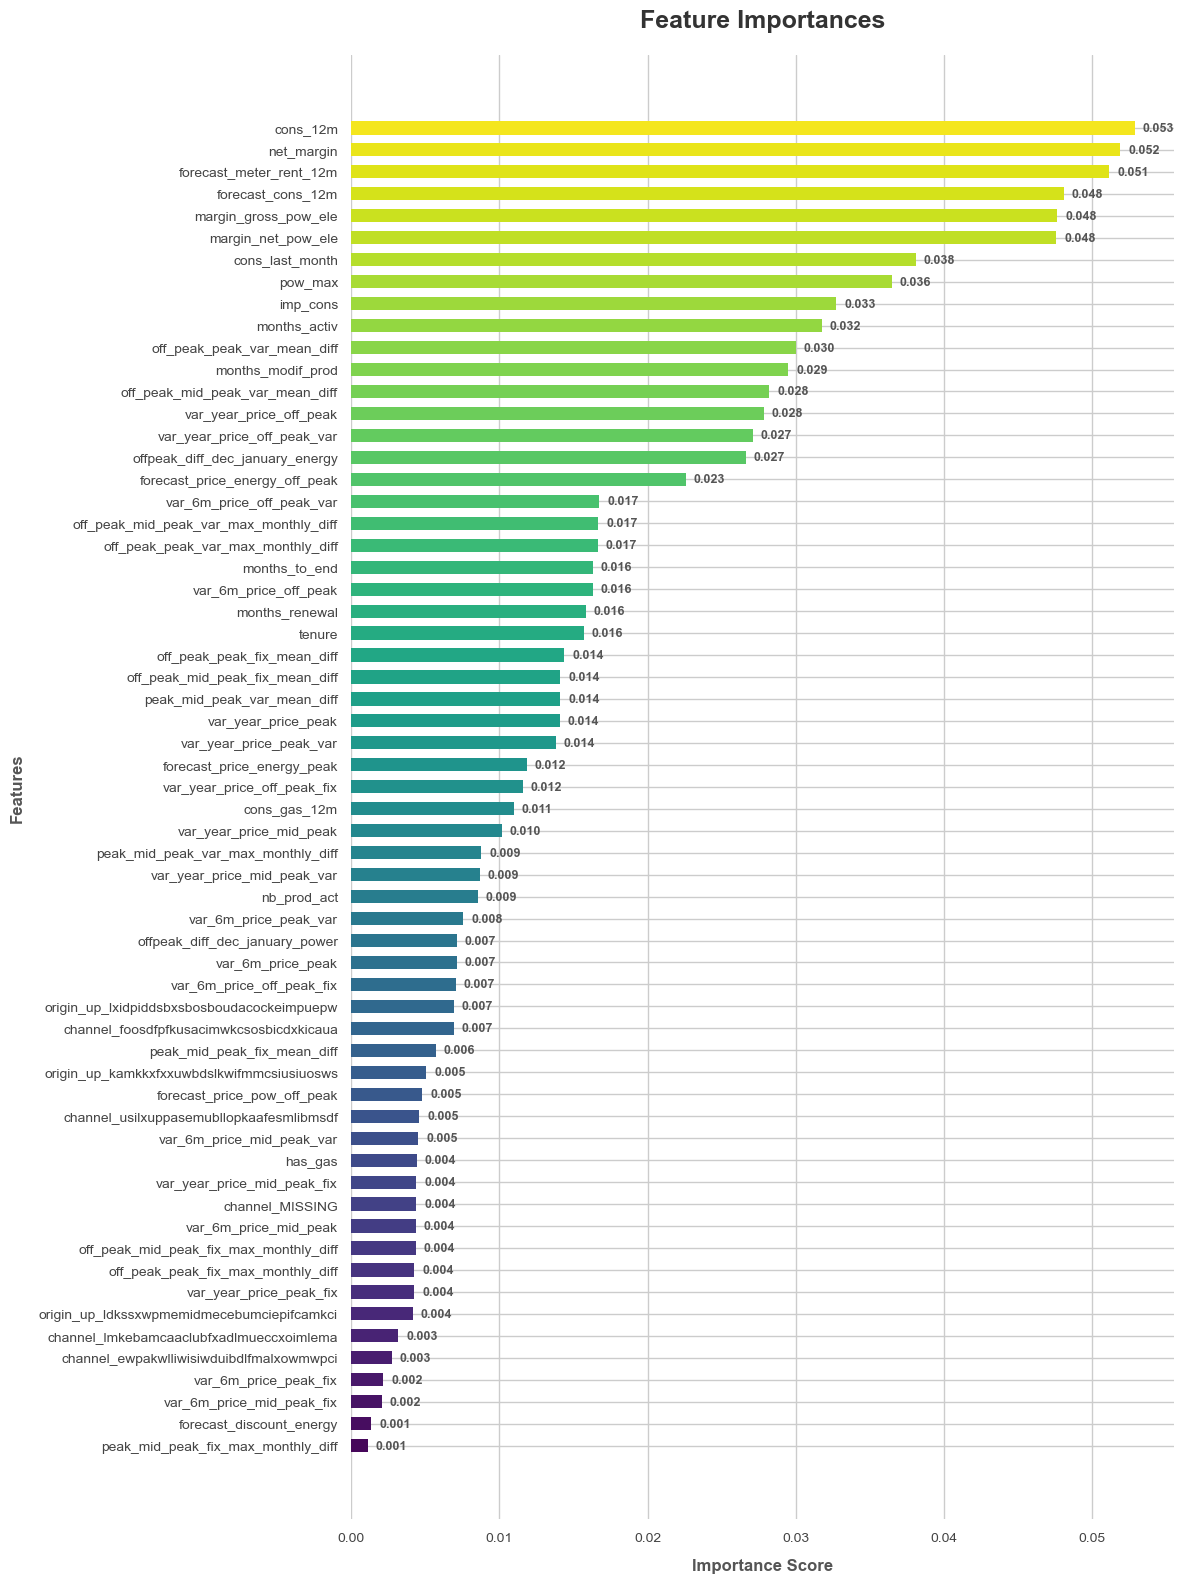

In [12]:

df_sorted = feature_importances.sort_values(by='importance', ascending=True)

sns.set_theme(style="whitegrid")

# 3. Initialize the figure with a well-proportioned size
fig, ax = plt.subplots(figsize=(12, 16))

colors = sns.color_palette("viridis", len(df_sorted))

bars = ax.barh(
    df_sorted['features'], 
    df_sorted['importance'], 
    color=colors, 
    edgecolor='none',
    height=0.6
)

# 5. Fine-tune
ax.set_title('Feature Importances', fontsize=18, fontweight='bold', pad=20, color='#333333')
ax.set_xlabel('Importance Score', fontsize=12, fontweight='semibold', labelpad=10, color='#555555')
ax.set_ylabel('Features', fontsize=12, fontweight='semibold', labelpad=10, color='#555555')

# Style the ticks
ax.tick_params(axis='both', which='major', labelsize=10, colors='#444444')

# 6. Add subtle values to the end of each bar for clarity
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (max(df_sorted['importance']) * 0.01),  # Small offset from the bar end
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',                                # Limited to 3 decimal places
        va='center', 
        ha='left', 
        fontsize=9, 
        color='#555555',
        weight='semibold'
    )

# Clean up the borders (spines) for a minimalist look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [13]:
proba_predictions = model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

In [14]:
X_test = X_test.reset_index()
X_test.drop(columns='index', inplace=True)

In [ ]:
# Save predictions and probabilities to CSV for further analysis
X_test['churn'] = predictions.tolist()
X_test['churn_probability'] = probabilities.tolist()
X_test.to_csv('out_of_sample_data_with_predictions.csv', index=False)

print("✓ Predictions saved to 'out_of_sample_data_with_predictions.csv'")

## Model Export for Production

Now we export the trained model and save it for use in production environments. This allows the model to be loaded and used without retraining.

In [ ]:
# Export trained model using joblib (preferred for scikit-learn models)
# This saves the entire model object including all parameters and learned patterns
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model
model_path = 'models/churn_model.pkl'
joblib.dump(model, model_path)

print(f"✓ Model successfully exported to '{model_path}'")
print(f"\nModel Details:")
print(f"  - Algorithm: Random Forest Classifier")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Number of features: {model.n_features_in_}")
print(f"  - Training accuracy: {accuracy:.1%}")